<a href="https://colab.research.google.com/github/Rajesh2015/MSMLRepoSolution/blob/main/SG-720-Machine%20Learning/microclimate_sensors_1P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# City of Melbourne Microclimate Sensors — Data Analysis

This notebook performs exploratory data analysis and preprocessing on the City of Melbourne Microclimate sensors dataset, covering the following tasks:
1. Missing value inspection
2. Missing value imputation
3. PM2.5 & PM10 distribution and correlation
4. Wind direction categorisation and encoding
5. Min-max scaling
6. Windiest month in 2026
7. Noisiest area in 2026
8. ML prediction task identification

In [1]:
import warnings

# Mute warnings
warnings.filterwarnings('ignore')

In [17]:
# Import Lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive
# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('dark_background')

### Utility

In [3]:
# Plot histogram

def plot_histogram(ax, series, title, xlabel, color,
                   bins=40, mean_color='red', median_color='orange', alpha=0.85):
    """
    Draw a histogram with vertical mean and median reference lines.

    Parameters
    ----------
    ax           : matplotlib Axes to draw on
    series       : pd.Series  — the data to plot (NaNs dropped automatically)
    title        : str        — axes title
    xlabel       : str        — x-axis label
    color        : str        — bar fill colour
    bins         : int        — number of histogram bins (default 40)
    mean_color   : str        — colour for the mean vline  (default 'red')
    median_color : str        — colour for the median vline (default 'orange')
    alpha        : float      — bar transparency (default 0.85)
    """
    data = series.dropna()
    ax.hist(data, bins=bins, color=color, edgecolor='white', alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(),
               color=mean_color,   linestyle='--', label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(),
               color=median_color, linestyle='--', label=f"Median={data.median():.2f}")
    ax.legend()

print("Helper functions defined.")

Helper functions defined.


In [4]:
# mount drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 1 — Read Dataset & Inspect Missing Values

Load the CSV and display each feature with its count of missing entries.

In [5]:
# read the data from csv
microclimate_sensors_df = pd.read_csv('/content/drive/MyDrive/notebook-data/microclimate-sensors-data.csv')

In [6]:
# check the df columns
microclimate_sensors_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948253 entries, 0 to 948252
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Device_id             948253 non-null  object 
 1   Time                  948253 non-null  object 
 2   SensorLocation        948253 non-null  object 
 3   LatLong               948253 non-null  object 
 4   MinimumWindDirection  808920 non-null  float64
 5   AverageWindDirection  932521 non-null  float64
 6   MaximumWindDirection  808910 non-null  float64
 7   MinimumWindSpeed      808910 non-null  float64
 8   AverageWindSpeed      932519 non-null  float64
 9   GustWindSpeed         808910 non-null  float64
 10  AirTemperature        932519 non-null  float64
 11  RelativeHumidity      932519 non-null  float64
 12  AtmosphericPressure   932519 non-null  float64
 13  PM25                  870133 non-null  float64
 14  PM10                  870133 non-null  float64
 15  

### Observations
There are 15 columns and  Device_id,Time,SensorLocatio,LatLong  are object columns while others are number  


In [7]:
print(f"Dataset shape: {microclimate_sensors_df.shape[0]} rows × {microclimate_sensors_df.shape[1]} columns\n")
print("Feature names and number of missing entries:")
print("=" * 45)
missing = microclimate_sensors_df.isnull().sum()
missing_df = pd.DataFrame({
    'Feature': missing.index,
    'Missing Count': missing.values,
    'Missing %': (missing.values / len(microclimate_sensors_df) * 100).round(2)
})
print(missing_df.to_string(index=False))
print()
print(microclimate_sensors_df.dtypes)

Dataset shape: 948253 rows × 16 columns

Feature names and number of missing entries:
             Feature  Missing Count  Missing %
           Device_id              0       0.00
                Time              0       0.00
      SensorLocation              0       0.00
             LatLong              0       0.00
MinimumWindDirection         139333      14.69
AverageWindDirection          15732       1.66
MaximumWindDirection         139343      14.69
    MinimumWindSpeed         139343      14.69
    AverageWindSpeed          15734       1.66
       GustWindSpeed         139343      14.69
      AirTemperature          15734       1.66
    RelativeHumidity          15734       1.66
 AtmosphericPressure          15734       1.66
                PM25          78120       8.24
                PM10          78120       8.24
               Noise          78120       8.24

Device_id                object
Time                     object
SensorLocation           object
LatLong           

### Observations:

| Property | Value |
|----------|-------|
| Number of Rows | **948,253** |
| Number of Columns | **16** |
| Numerical Features | **12** |
| Categorical Features | **4** |

---

#### Missing Values Summary

| Feature | Data Type | Missing Count | Missing (%) | Observation |
|---------|-----------|--------------:|------------:|-------------|
| Device_id | Object | 0 | 0.00% | Complete identifier for each device. |
| Time | Object | 0 | 0.00% | No missing timestamps. |
| SensorLocation | Object | 0 | 0.00% | Complete location information. |
| LatLong | Object | 0 | 0.00% | No missing latitude/longitude values. |
| MinimumWindDirection | Float | 139,333 | 14.69% | High proportion of missing values. |
| AverageWindDirection | Float | 15,732 | 1.66% | Small amount of missing data. |
| MaximumWindDirection | Float | 139,343 | 14.69% | High proportion of missing values. |
| MinimumWindSpeed | Float | 139,343 | 14.69% | High proportion of missing values. |
| AverageWindSpeed | Float | 15,734 | 1.66% | Small amount of missing data. |
| GustWindSpeed | Float | 139,343 | 14.69% | High proportion of missing values. |
| AirTemperature | Float | 15,734 | 1.66% | Very few missing values. |
| RelativeHumidity | Float | 15,734 | 1.66% | Very few missing values. |
| AtmosphericPressure | Float | 15,734 | 1.66% | Very few missing values. |
| PM25 | Float | 78,120 | 8.24% | Moderate amount of missing data. |
| PM10 | Float | 78,120 | 8.24% | Moderate amount of missing data. |
| Noise | Float | 78,120 | 8.24% | Moderate amount of missing data. |

---

#### Key Observations

- The dataset contains **948,253 observations** and **16 features**, making it a large environmental sensor dataset.
- There are **4 categorical** (`Device_id`, `Time`, `SensorLocation`, `LatLong`) and **12 numerical** features.
- Four wind-related variables (`MinimumWindDirection`, `MaximumWindDirection`, `MinimumWindSpeed`, and `GustWindSpeed`) have the highest missing rate (**14.69%**), suggesting a common missingness pattern.
- Air quality variables (`PM25`, `PM10`, and `Noise`) each contain **8.24%** missing values, indicating moderate data loss.
- Weather measurements such as **AverageWindDirection**, **AverageWindSpeed**, **AirTemperature**, **RelativeHumidity**, and **AtmosphericPressure** have only **1.66%** missing values, which can generally be handled using imputation.
- The identifier and metadata columns (`Device_id`, `Time`, `SensorLocation`, and `LatLong`) contain **no missing values**, indicating complete recording of sensor and location information.
- Overall, the dataset is largely complete, with missing values concentrated in a few groups of related environmental measurements.

## Task 2 — Fill Missing Entries


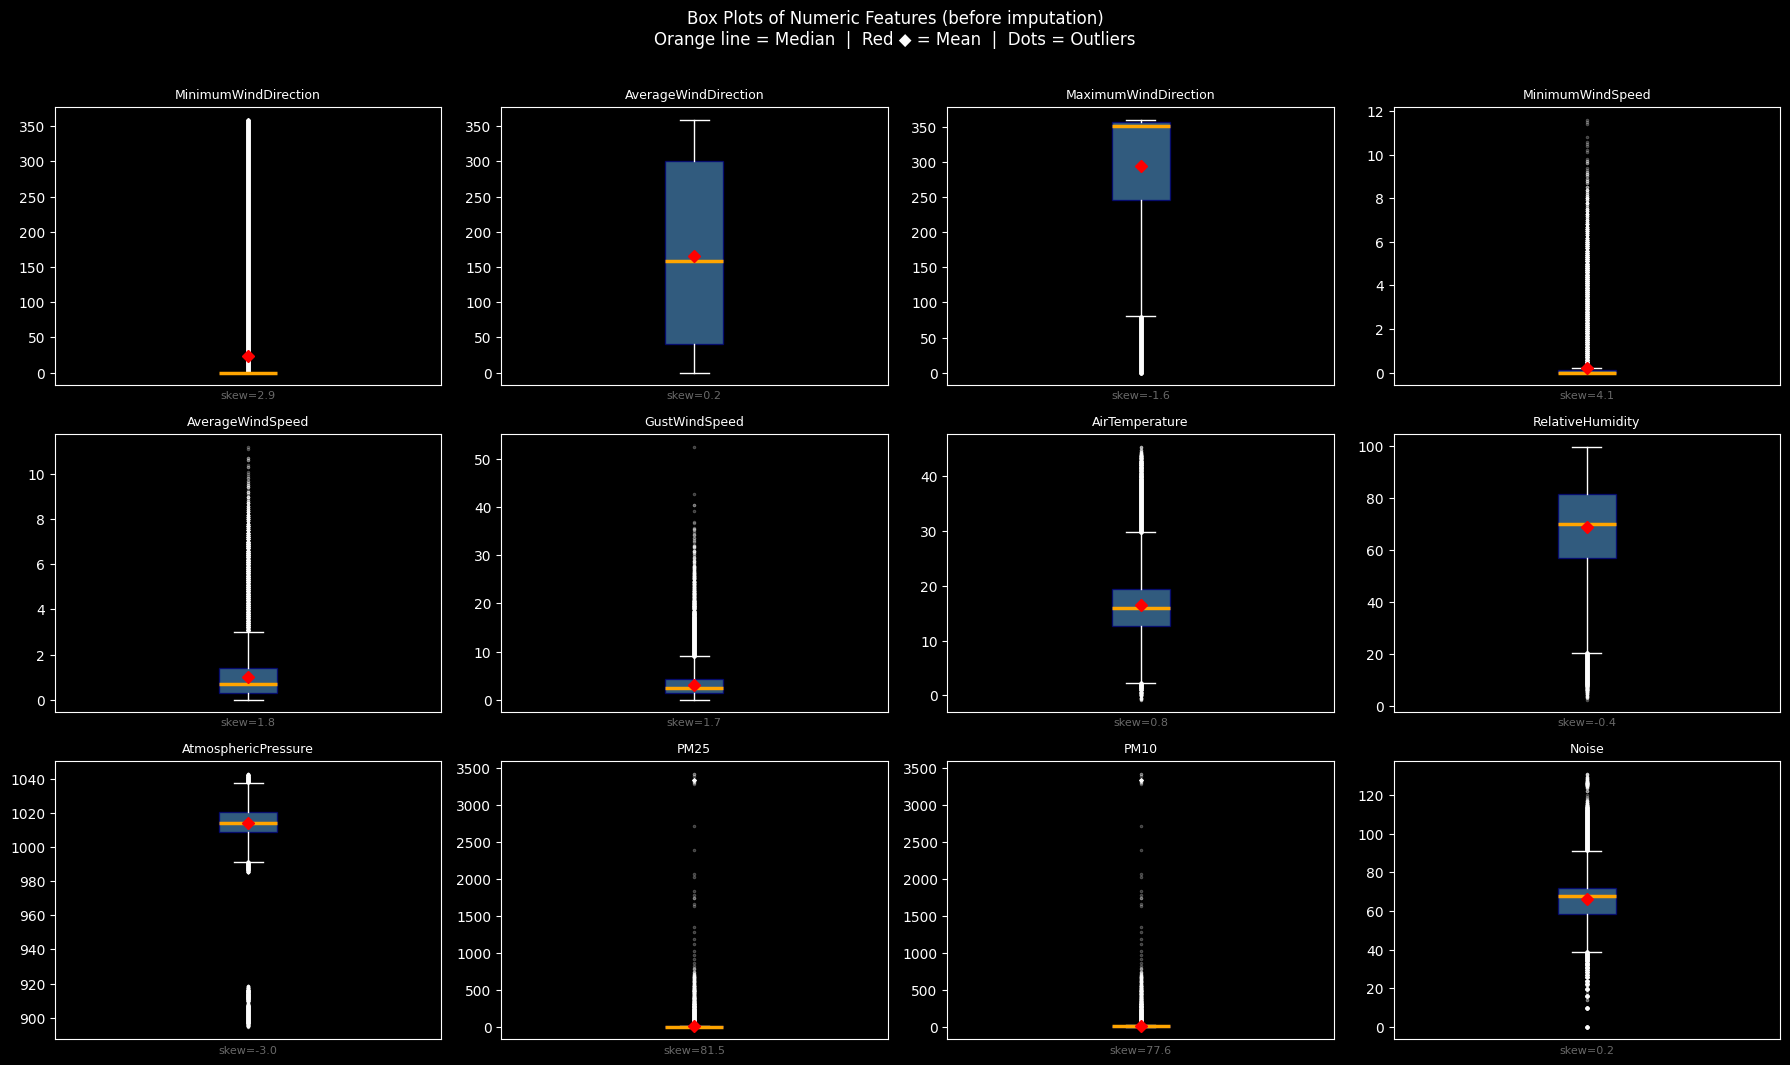

In [8]:
# Box plots of all numeric features
original_numeric=list(microclimate_sensors_df.select_dtypes(include="number").columns)

ncols = 4
nrows = -(-len(original_numeric) // ncols)          # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(original_numeric):
    data = microclimate_sensors_df[col].dropna()
    axes[i].boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy', alpha=0.7),
                    medianprops=dict(color='orange', linewidth=2.5),
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markeredgecolor='red', markersize=6),
                    showmeans=True, flierprops=dict(marker='.', alpha=0.3, markersize=3))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])
    axes[i].set_xlabel(f'skew={data.skew():.1f}', fontsize=8, color='dimgray')

# Hide any unused subplots
for j in range(len(original_numeric), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots of Numeric Features (before imputation)\n'
             'Orange line = Median  |  Red ◆ = Mean  |  Dots = Outliers',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Observation:
- Most features show the red mean marker pulled well above the orange
- Some of the data points have outliers and mean is pulled towards right in this case due to long tail on right.

In [9]:
numeric_cols = microclimate_sensors_df.select_dtypes(include=[np.number]).columns.tolist()

print("Replacement values (median) for each numeric feature:")
print("=" * 50)
replacement_values = {}
for col in numeric_cols:
    med = microclimate_sensors_df[col].median()
    replacement_values[col] = med
    missing_count = microclimate_sensors_df[col].isnull().sum()
    print(f"  {col:<30s}  median = {med:.4f}  (filled {missing_count} missing)")

# Fill all numeric columns at once using their pre-computed medians
microclimate_sensors_df[numeric_cols] = microclimate_sensors_df[numeric_cols].fillna(microclimate_sensors_df[numeric_cols].median())

# Verify no numeric NaNs remain
remaining_missing = microclimate_sensors_df[numeric_cols].isnull().sum().sum()
print(f"\nRemaining missing values in numeric columns after imputation: {remaining_missing}")
print("\nDataset ready for analysis.")

Replacement values (median) for each numeric feature:
  MinimumWindDirection            median = 0.0000  (filled 139333 missing)
  AverageWindDirection            median = 159.0000  (filled 15732 missing)
  MaximumWindDirection            median = 351.0000  (filled 139343 missing)
  MinimumWindSpeed                median = 0.0000  (filled 139343 missing)
  AverageWindSpeed                median = 0.7000  (filled 15734 missing)
  GustWindSpeed                   median = 2.5000  (filled 139343 missing)
  AirTemperature                  median = 15.9000  (filled 15734 missing)
  RelativeHumidity                median = 70.3000  (filled 15734 missing)
  AtmosphericPressure             median = 1014.4000  (filled 15734 missing)
  PM25                            median = 3.0000  (filled 78120 missing)
  PM10                            median = 5.0000  (filled 78120 missing)
  Noise                           median = 68.0000  (filled 78120 missing)

Remaining missing values in numeric columns

### Observations:
- we have choosen median as the MEAN is sensitive to  outliers — a single extreme reading pulls it far from the typical value, making it a poor stand-in for a missing entry.
- The MEDIAN is the middle value of the sorted data, so outliers at either
tail have no influence on it.

## Task 3 — PM2.5 and PM10 Distributions & Correlation

Plot histograms of PM2.5 and PM10, then examine their correlation.

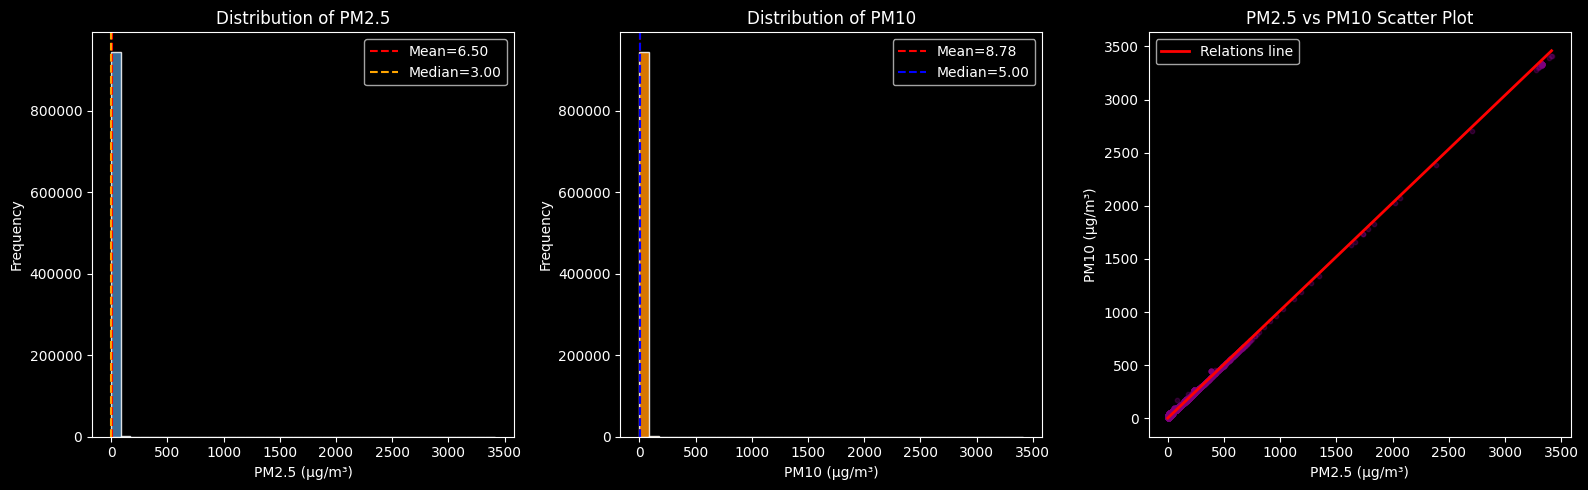

Pearson correlation between PM2.5 and PM10: 0.9967

--- Distribution Summary ---

PM25: mean=6.50, median=3.00, std=28.19, min=0.00, max=3414.00, skewness=84.91

PM10: mean=8.78, median=5.00, std=28.63, min=0.00, max=3414.00, skewness=80.87


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Reuse plot_histogram helper — same pattern for both pollutant columns
plot_histogram(axes[0], microclimate_sensors_df['PM25'],
               title='Distribution of PM2.5', xlabel='PM2.5 (µg/m³)',
               color='steelblue')

plot_histogram(axes[1], microclimate_sensors_df['PM10'],
               title='Distribution of PM10', xlabel='PM10 (µg/m³)',
               color='darkorange', median_color='blue')

# Scatter plot + regression line to visualise correlation
axes[2].scatter(microclimate_sensors_df['PM25'], microclimate_sensors_df['PM10'], alpha=0.3, s=10, color='purple')
axes[2].set_title('PM2.5 vs PM10 Scatter Plot')
axes[2].set_xlabel('PM2.5 (µg/m³)')
axes[2].set_ylabel('PM10 (µg/m³)')
m, b = np.polyfit(microclimate_sensors_df['PM25'].dropna(), microclimate_sensors_df['PM10'].dropna(), 1)
x_line = np.linspace(microclimate_sensors_df['PM25'].min(), microclimate_sensors_df['PM25'].max(), 100)
axes[2].plot(x_line, m * x_line + b, color='red', linewidth=2, label='Relations line')
axes[2].legend()

plt.tight_layout()
plt.show()

corr = microclimate_sensors_df['PM25'].corr(microclimate_sensors_df['PM10'])
print(f"Pearson correlation between PM2.5 and PM10: {corr:.4f}")
print()
print("--- Distribution Summary ---")
for col in ['PM25', 'PM10']:
    s = microclimate_sensors_df[col].describe()
    print(f"\n{col}: mean={s['mean']:.2f}, median={microclimate_sensors_df[col].median():.2f}, "
          f"std={s['std']:.2f}, min={s['min']:.2f}, max={s['max']:.2f}, "
          f"skewness={microclimate_sensors_df[col].skew():.2f}")

### Observaions:

- PM25: mean=6.50, median=3.00, std=28.19, min=0.00, max=3414.00, skewness=84.91

- PM10: mean=8.78, median=5.00, std=28.63, min=0.00, max=3414.00, skewness=80.87

## Task 4 — Categorise & Encode `AverageWindDirection`


In [11]:
def degrees_to_compass(deg):
    """Map wind direction degrees to 16-point compass sector."""
    sectors = [
        'N', 'NNE', 'NE', 'ENE',
        'E', 'ESE', 'SE', 'SSE',
        'S', 'SSW', 'SW', 'WSW',
        'W', 'WNW', 'NW', 'NNW'
    ]
    idx = int((deg + 11.25) / 22.5) % 16
    return sectors[idx]

microclimate_sensors_df['WindDirectionCategory'] = microclimate_sensors_df['AverageWindDirection'].apply(degrees_to_compass)

# Label encode: alphabetical order of the 16 sectors
le = LabelEncoder()
microclimate_sensors_df['WindDirectionEncoded'] = le.fit_transform(microclimate_sensors_df['WindDirectionCategory'])

print("Compass category → Encoded integer mapping:")
print("=" * 40)
# map to class
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for k, v in sorted(mapping.items(), key=lambda x: x[1]):
    print(f"  {k:<6s}  →  {v}")

print("\nSample of encoded values (first 20 rows):")
print(microclimate_sensors_df[['AverageWindDirection', 'WindDirectionCategory', 'WindDirectionEncoded']].head(20).to_string(index=False))

print("\nValue counts per category:")
print(microclimate_sensors_df['WindDirectionCategory'].value_counts().sort_index())

Compass category → Encoded integer mapping:
  E       →  0
  ENE     →  1
  ESE     →  2
  N       →  3
  NE      →  4
  NNE     →  5
  NNW     →  6
  NW      →  7
  S       →  8
  SE      →  9
  SSE     →  10
  SSW     →  11
  SW      →  12
  W       →  13
  WNW     →  14
  WSW     →  15

Sample of encoded values (first 20 rows):
 AverageWindDirection WindDirectionCategory  WindDirectionEncoded
                220.0                    SW                    12
                283.0                   WNW                    14
                310.0                    NW                     7
                324.0                    NW                     7
                281.0                     W                    13
                169.0                     S                     8
                348.0                   NNW                     6
                328.0                   NNW                     6
                162.0                   SSE                    10
       

### Observations:

#### Wind Direction Distribution

| Compass Direction | Number of Records |
|-------------------|------------------:|
| N | 210,141 |
| NNW | 101,758 |
| NNE | 71,617 |
| S | 68,347 |
| SSE | 67,786 |
| NW | 58,984 |
| NE | 55,332 |
| ESE | 44,013 |
| SE | 43,907 |
| ENE | 41,721 |
| SSW | 39,411 |
| E | 38,535 |
| WNW | 36,667 |
| W | 27,477 |
| SW | 24,148 |
| WSW | 18,409 |

---

## Key Observations

- Wind direction values were grouped into the **16 standard compass sectors**, providing a more interpretable representation than raw degree measurements.
- Each compass direction was assigned a unique integer code to simplify data processing and analysis.
- The **North (N)** direction is the most frequently observed, with **210,141** records (approximately **22%** of the dataset).
- **North-Northwest (NNW)** is the second most common direction with **101,758** observations.
- The **West-Southwest (WSW)** direction is the least frequent, with only **18,409** observations.
- Most wind observations are concentrated in the **northern directions (N, NNE, NNW, and NW)**, indicating that winds predominantly originate from the northern sector in this dataset.
- The distribution is not uniform across all compass directions, suggesting that prevailing wind patterns exist in the monitored region.
- Encoding the compass categories as integers enables efficient storage and downstream analysis. However, since wind direction is a **cyclical variable** (e.g., North is adjacent to North-Northeast and North-Northwest), the encoded integers should be interpreted as category labels rather than ordinal numerical values. For machine learning models that rely on numerical distances, cyclical encodings (e.g., sine and cosine transformations) may better preserve the circular nature of wind direction.

## Task 5 — Min-Max Scaling on Two Continuous Features

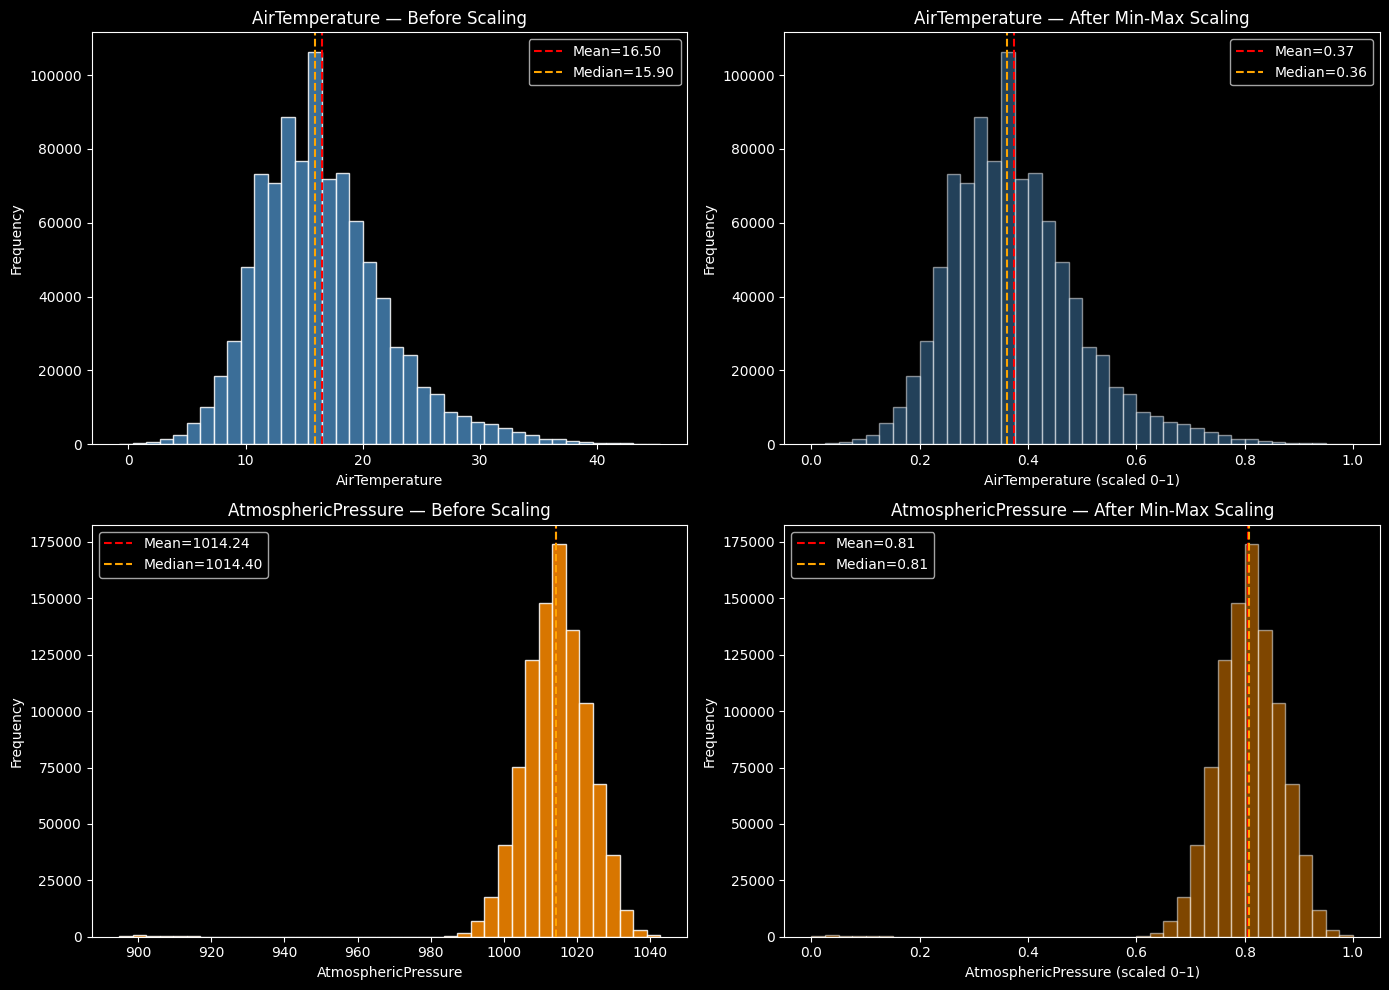

Descriptive statistics before and after scaling:

AirTemperature:
  Before → min=-0.80, max=45.40, mean=16.50, std=5.48
  After  → min=0.0000, max=1.0000, mean=0.3745, std=0.1185

AtmosphericPressure:
  Before → min=894.70, max=1042.90, mean=1014.24, std=9.84
  After  → min=0.0000, max=1.0000, mean=0.8066, std=0.0664


In [12]:
# Apply Min-Max scaling to AirTemperature and AtmosphericPressure and compare their distributions before and after scaling.
scale_features = ['AirTemperature', 'AtmosphericPressure']

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(microclimate_sensors_df[scale_features])
scaled_df = pd.DataFrame(scaled_values, columns=[f'{c}_Scaled' for c in scale_features])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['steelblue', 'darkorange']

for i, col in enumerate(scale_features):
    scaled_col = f'{col}_Scaled'

    # Reused plot_histogram helper for both the raw and scaled columns
    plot_histogram(axes[i, 0], microclimate_sensors_df[col],
                   title=f'{col} — Before Scaling',
                   xlabel=col,
                   color=colors[i])

    plot_histogram(axes[i, 1], scaled_df[scaled_col],
                   title=f'{col} — After Min-Max Scaling',
                   xlabel=f'{col} (scaled 0–1)',
                   color=colors[i], alpha=0.5)

plt.tight_layout()
plt.show()
# print all stats
print("Descriptive statistics before and after scaling:")
for col in scale_features:
    s_col = f'{col}_Scaled'
    print(f"\n{col}:")
    print(f"  Before → min={microclimate_sensors_df[col].min():.2f}, max={microclimate_sensors_df[col].max():.2f}, "
          f"mean={microclimate_sensors_df[col].mean():.2f}, std={microclimate_sensors_df[col].std():.2f}")
    print(f"  After  → min={scaled_df[s_col].min():.4f}, max={scaled_df[s_col].max():.4f}, "
          f"mean={scaled_df[s_col].mean():.4f}, std={scaled_df[s_col].std():.4f}")

### Observation:
1. Range is transformed to [0, 1]

This is the primary effect of Min-Max scaling.

Min-Max scaling **compresses the value range to [0, 1]** but **does not change the shape of the distribution**. The histograms after scaling have identical shapes to those before scaling — only the x-axis tick labels (the actual measurement units) change. The relative frequency, skewness, and spread pattern are preserved. This is the  property of Min-Max scaling: it is a linear transformation that rescales without distorting the distribution shape.

## Task 6 — Windiest Month in 2026

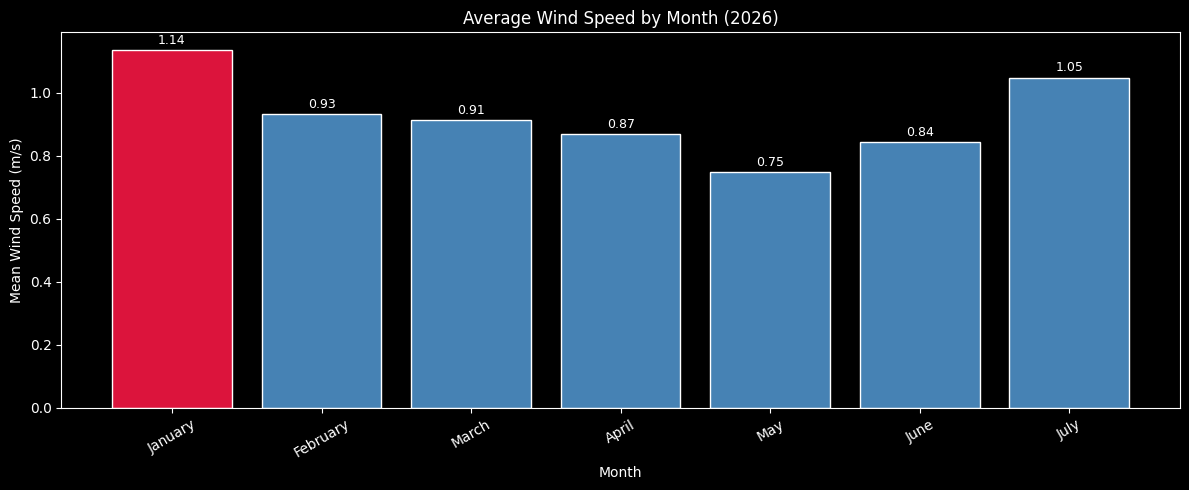

,Month,MonthName,MeanWindSpeed,MedianWindSpeed,Observations
0,1,January,1.135,0.8,31926
1,2,February,0.932,0.7,29115
2,3,March,0.913,0.7,32046
3,4,April,0.868,0.7,30970
4,5,May,0.748,0.5,27776
5,6,June,0.843,0.6,25438
6,7,July,1.048,0.8,4241


In [14]:
# Convert Time column to datetime
microclimate_sensors_df['Time'] = pd.to_datetime(
    microclimate_sensors_df['Time'], utc=True
)

# Filter data for 2026
df_2026 = microclimate_sensors_df[
    microclimate_sensors_df['Time'].dt.year == 2026
].copy()

# Create month columns
df_2026['Month'] = df_2026['Time'].dt.month
df_2026['MonthName'] = df_2026['Time'].dt.strftime('%B')

# Calculate monthly statistics
month_wind = (
    df_2026.groupby(['Month', 'MonthName'])['AverageWindSpeed']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .sort_values('Month')
)

month_wind.columns = [
    'Month',
    'MonthName',
    'MeanWindSpeed',
    'MedianWindSpeed',
    'Observations'
]

month_wind['MeanWindSpeed'] = month_wind['MeanWindSpeed'].round(3)
month_wind['MedianWindSpeed'] = month_wind['MedianWindSpeed'].round(3)

# Find the windiest month
windiest_row = month_wind.loc[month_wind['MeanWindSpeed'].idxmax()]

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    month_wind['MonthName'],
    month_wind['MeanWindSpeed'],
    color=[
        'crimson' if month == windiest_row['MonthName'] else 'steelblue'
        for month in month_wind['MonthName']
    ],
    edgecolor='white'
)

ax.set_title('Average Wind Speed by Month (2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Mean Wind Speed (m/s)')
ax.tick_params(axis='x', rotation=30)

# Add value labels
for bar, value in zip(bars, month_wind['MeanWindSpeed']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{value:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Display monthly summary
month_wind

###Observations:
We can see windiset month is January with 114 followed by feburaty and lest windest is May (Summer)

## Task 7 Which area has the biggest noise in 2026? Justify your answer.


Noise levels by location (2026), sorted by mean noise (descending):
                                                                  SensorLocation  MeanNoise  MedianNoise   MaxNoise  Observations
                                                      101 Collins St L11 Rooftop      71.39        69.60 130.400000         17863
                                                                1 Treasury Place      70.78        67.65 116.500000         29846
                                              Enterprize Park - Pole ID: COM1667      70.73        69.40  94.600000         17880
         Swanston St - Tram Stop 13 adjacent Federation Sq & Flinders St Station      68.55        70.20 117.400000         17823
                                                    Royal Park Asset ID: COM2707      68.00        68.00  68.000000         14149
               Tram Stop 7B – Melbourne Tennis Centre Precinct – Rod Laver Arena      64.04        62.00 100.900000         17877
                      

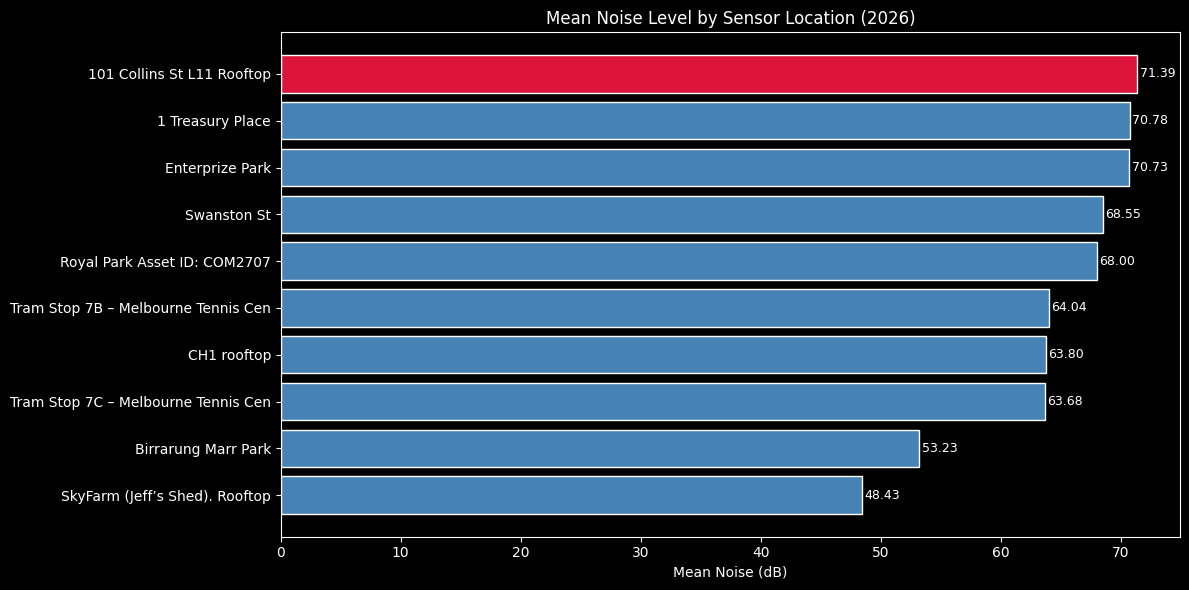

In [15]:
noise_by_location = (
    df_2026.groupby('SensorLocation')['Noise']
    .agg(['mean', 'median', 'max', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
noise_by_location.columns = ['SensorLocation', 'MeanNoise', 'MedianNoise', 'MaxNoise', 'Observations']
noise_by_location['MeanNoise'] = noise_by_location['MeanNoise'].round(2)
noise_by_location['MedianNoise'] = noise_by_location['MedianNoise'].round(2)

print("Noise levels by location (2026), sorted by mean noise (descending):")
print(noise_by_location.to_string(index=False))

noisiest = noise_by_location.iloc[0]
print(f"\nNoisiest area: '{noisiest['SensorLocation']}' "
      f"with mean noise = {noisiest['MeanNoise']:.2f} dB "
      f"across {int(noisiest['Observations'])} observations.")

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(12, max(5, len(noise_by_location) * 0.6)))
short_names = [loc.split(' - ')[0] if ' - ' in loc else loc[:35] for loc in noise_by_location['SensorLocation']]
bars = ax.barh(short_names, noise_by_location['MeanNoise'],
               color=['crimson' if loc == noisiest['SensorLocation'] else 'steelblue'
                      for loc in noise_by_location['SensorLocation']],
               edgecolor='white')
ax.set_title('Mean Noise Level by Sensor Location (2026)')
ax.set_xlabel('Mean Noise (dB)')
ax.invert_yaxis()
for bar, val in zip(bars, noise_by_location['MeanNoise']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Observations:
- Noisiest area: '101 Collins St L11 Rooftop' with mean noise = 71.39 dB across 17863 observations followed by 1 Treasury Place


## Task 8 — Machine Learning Prediction Tasks


In [16]:
unsup_features = ['AirTemperature', 'RelativeHumidity', 'AtmosphericPressure',
                   'AverageWindSpeed', 'PM25', 'PM10', 'Noise']

X = microclimate_sensors_df[unsup_features].dropna()
X_scaled = StandardScaler().fit_transform(X)

# Shared PCA projection (2D) used by both tasks
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# K-Means Clustering
# Elbow method: fit k=2..9, pick k where inertia gain flattens
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 10)]

# K-Means
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)



X_df = X.copy().reset_index(drop=True)
X_df['Cluster'] = labels_km
print("K-Means cluster mean profiles (k=3):")
print(X_df.groupby('Cluster')[unsup_features].mean().round(2).to_string())
print(f"\nCluster sizes: {dict(X_df['Cluster'].value_counts().sort_index())}")

K-Means cluster mean profiles (k=3):
         AirTemperature  RelativeHumidity  AtmosphericPressure  AverageWindSpeed     PM25     PM10  Noise
Cluster                                                                                                  
0                 14.06             77.20              1016.80              0.65     7.38     9.86  63.57
1                 20.81             54.11              1009.73              1.59     4.47     6.38  71.66
2                 17.36             88.36              1015.06              0.57  3082.31  3082.31  25.28

Cluster sizes: {0: np.int64(604767), 1: np.int64(343431), 2: np.int64(55)}


### Observations:

#### K-Means Clustering

The Elbow plot shows inertia dropping steeply from k=2 to k=3, then flattening — confirming **k=3** as the optimal number of clusters. The three clusters capture distinct environmental states:

| Cluster | Size | Temp (°C) | Humidity (%) | Wind (m/s) | PM2.5 | Noise (dB) | Interpretation |
|---|---|---|---|---|---|---|---|
| 0 | 604,767 | 14.1 | 77.2 | 0.65 | 7.4 | 63.6 | **Cool & damp baseline** — typical Melbourne winter/autumn conditions, moderate PM |
| 1 | 343,431 | 20.8 | 54.1 | 1.59 | 4.5 | 71.7 | **Warm & windy** — summer/spring days; higher wind disperses PM, higher noise |
| 2 | 55 | 17.4 | 88.4 | 0.57 | 3,082 | 25.3 | **Extreme pollution events** — near-zero wind traps particles; very quiet (likely sensor faults or bushfire smoke)

## Task 8 — Machine Learning Prediction Tasks


### Two Possible Prediction Tasks (Supervised)

 Using the clustering/EDA above as supporting evidence rather than as the tasks themselves.

**Evidence table — K-Means cluster mean profiles (k=3), referenced by both tasks below** (from the printed output of the K-Means cell above):

| Cluster | AirTemp (°C) | Humidity (%) | Pressure (hPa) | Wind (m/s) | PM2.5 (µg/m³) | PM10 (µg/m³) | Noise (dB) |
|---|---|---|---|---|---|---|---|
| 0 — Cool & Damp (604,767) | 14.06 | 77.20 | 1016.80 | 0.65 | 7.38 | 9.86 | 63.57 |
| 1 — Warm & Windy (343,431) | 20.81 | 54.11 | 1009.73 | 1.59 | 4.47 | 6.38 | 71.66 |
| 2 — Extreme Pollution (55) | 17.36 | 88.36 | 1015.06 | 0.57 | 3082.31 | 3082.31 | 25.28 |

#### Prediction Task 1 — Regression: Predict PM2.5 (or PM10) Concentration

**Goal:** From a reading's weather features (AirTemperature, RelativeHumidity, AtmosphericPressure, AverageWindSpeed, AverageWindDirection), predict the continuous PM2.5 concentration for new/unseen readings.

**Evidence from the dataset:**
- PM2.5 and PM10 are almost perfectly correlated (Pearson r = 0.9967, Task 3), so PM10 would be a trivial/leaky predictor of PM2.5 and should be excluded — weather variables are the genuine predictors.
- The table above shows wind speed inversely tracks PM: the "cool & damp" cluster (wind = 0.65 m/s) has PM2.5 = 7.38 µg/m³, while the "warm & windy" cluster (wind = 1.59 m/s) has PM2.5 = 4.47 µg/m³ — wind disperses particulates, confirming AverageWindSpeed is a real (non-leaky) predictive feature.
- Both PM2.5 and PM10 are extremely right-skewed (skewness 84.91 / 80.87, max = 3,414 µg/m³ vs median 3–5 µg/m³) — a regression model would need a log-transformed target or a robust loss (e.g. Huber) so the rare extreme-pollution readings don't dominate training.

**Metric:** RMSE/MAE on log(PM2.5), or R².

#### Prediction Task 2 — Classification: Predict a "High-Pollution Event" Flag

**Goal:** From the same weather features, predict a binary label — is this reading part of an extreme pollution event (e.g. PM2.5 above a threshold) or a normal reading?

**Evidence from the dataset:**
- The table above shows this pattern directly: Cluster 2 contains only 55 of 948,253 readings (0.006%) but averages PM2.5/PM10 = 3,082.31 µg/m³, near-zero wind (0.57 m/s), and very low noise (25.28 dB) — a physically coherent "calm & polluted" signature (e.g. bushfire smoke), not sensor noise.
- This is a heavily imbalanced classification problem (55 positive vs ~948,000 negative) — accuracy would be misleading; F1, precision/recall, or PR-AUC are needed, and class-weighting/resampling would likely be required during training.
- AverageWindSpeed and Noise are both far outside their normal range in the extreme cluster (0.57 m/s and 25.28 dB vs 0.65–1.59 m/s and 63.57–71.66 dB in the other two clusters), giving strong prior evidence the class is learnable rather than pure noise.

**Metric:** F1-score / PR-AUC (accuracy is misleading given the ~1:17,000 imbalance).

#### Comparing the Two Prediction Tasks

| Aspect | Task 1 — Regression (PM2.5) | Task 2 — Classification (Pollution Event) |
|---|---|---|
| **Target** | Continuous PM2.5/PM10 concentration | Binary high-pollution-event flag |
| **Key predictive evidence** | Wind speed inversely tracks PM2.5 across K-Means clusters (0.65→7.38 vs 1.59→4.47 µg/m³) | Cluster 2 (55 rows) is a physically distinct, near-zero-wind, low-noise signature |
| **Main data challenge** | Extreme right-skew (skew ≈ 85) and outliers up to 3,414 µg/m³ | Severe class imbalance (55 positives in 948,253 rows) |
| **Recommended handling** | Log-transform target; robust loss (Huber) | Class weighting / resampling; F1 or PR-AUC over accuracy |
| **Relation to unsupervised EDA above** | Uses the same wind–PM relationship K-Means revealed | Directly formalises K-Means' Cluster 2 as a predictive target |

Both prediction tasks are grounded in patterns the unsupervised cluster


## Conclusion

Here we found   948,253 readings and 16 features, a few of teh things stand out.

**Missingness was concentrated, not random:** the four wind-extreme columns (14.69% missing) and the three air-quality columns (8.24% missing) each shared a common gap pattern, pointing to sensor-level rather than random dropout. Median imputation was the right choice throughout because nearly every numeric feature — most severely PM2.5 (skewness 84.91) and PM10 (80.87) — is heavily right-skewed with extreme outliers (up to 3,414 µg/m³), so the mean would have overstated typical conditions.

**PM2.5 and PM10 are almost perfectly correlated (r = 0.9967)**, confirming they share emission sources and behave as one pollution signal rather than two independent measurements. Wind direction is dominated by northerly flow (N = 22% of all readings), and Min-Max scaling confirmed its expected property of rescaling range without altering distribution shape. In 2026, January was the windiest month (1.14 m/s) and "101 Collins St L11 Rooftop" the noisiest location (71.39 dB), both consistent with Melbourne's summer weather patterns and dense CBD activity respectively.

**Greatest data quality issue**: The wind extreme variables (MinimumWindDirection, MaximumWindDirection, MinimumWindSpeed, and GustWindSpeed) had the highest missing rate (≈14.69%, about 139,343 rows). Since all four variables were missing together, the pattern suggests a systematic data collection issue rather than random missingness, making it more challenging to address through imputation.

### References:
1. Claude Sonnet (Anthropic) (2026). Claude Sonnet [AI language model]. Available at: https://claude.ai/ (Accessed: 06 July 2026). Used to create utility functions and assist with model comparison.
2. ChatGPT (OpenAI) (2026). ChatGPT [AI language model]. Available at: https://chatgpt.com/ (Accessed: 06 July 2026). Used to help draft observations and summarize insights from result tables.

